# Cài đặt thư viện, module và đọc dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm
from scipy.stats import ks_2samp, chi2_contingency
import gdown
import warnings
warnings.filterwarnings('ignore')

In [ ]:
drive_files = {
    'geography': '1AoHEINjy0G6evkcn6G0ZQlSrRi-H8sCw',
    'reviews': '11uSO9FqGruJxtwiAtbOrn0bYqembKjky',
    'customers': '1zOJVpKAvyZDhjrv8oN5X3q-8ESt7nK0C',
    'payments': '1uauLXN2gHWTuN1Hznp9Bi98Z58PNyqZX',
    'shipments': '1Lhsc127N9EBu0rQTWrBMPjo9RJ0bxXQq',
    'df_order': '1qgJAYEH1M5w5syZCHsCof4v5yYHDglZ8',
    'df_order_item': '189g8Scbtk_bwKeLgu1V93UMw9uMWYcC_'
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

geography = dfs['geography']
reviews = dfs['reviews']
customers = dfs['customers']
payments = dfs['payments']
shipments = dfs['shipments']
df_order = dfs['df_order']
df_order_item = dfs['df_order_item']

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: geography
Đã tải xong: reviews
Đã tải xong: customers
Đã tải xong: payments
Đã tải xong: shipments
Đã tải xong: df_order
Đã tải xong: df_order_item


In [ ]:
!gdown --id 14qm03mDlqc7ehI24zXSKO2C-Ah1wf088
import EDA_classes

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14qm03mDlqc7ehI24zXSKO2C-Ah1wf088
From (redirected): https://drive.google.com/uc?id=14qm03mDlqc7ehI24zXSKO2C-Ah1wf088&confirm=t&uuid=2a608d36-048f-4ba3-9c21-9f4b9fbd2c3d
To: /content/EDA_classes.py
100% 30.2k/30.2k [00:00<00:00, 36.7MB/s]


In [ ]:
from EDA_classes import EDA as EDA
from EDA_classes import DistributionAnalyzer as DistributionAnalyzer
from EDA_classes import CorrelationAnalyzer as CorrelationAnalyzer
from EDA_classes import DuplicateAndNullAnalyzer as DuplicateAndNullAnalyzer

# EDA

## orders

### Tổng quan

In [ ]:
eda_order = EDA_classes.EDA(df=df_order)
distribution_analyzer_order = EDA_classes.DistributionAnalyzer(eda_order.df)
duplicate_and_null_analyzer_order = EDA_classes.DuplicateAndNullAnalyzer(eda_order.df)
correlation_analyzer_order = EDA_classes.CorrelationAnalyzer(eda_order.df)

In [ ]:
eda_order.df.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [ ]:
eda_order.display_shape()


--- Kích thước của dataframe ---
(646945, 8)


In [ ]:
eda_order.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


File hoàn toàn sạch, không chứa giá trị null.

### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer_order.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


In [ ]:
duplicate_and_null_analyzer_order.missing_check()


--- Kiểm tra dữ liệu thiếu ---
order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64


### Phân phối của dữ liệu

In [ ]:
distribution_analyzer_order.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
            order_id    customer_id            zip
count  646945.000000  646945.000000  646945.000000
mean   417189.470332   84906.203535   55410.740423
std    240785.704463   48446.922752   28876.471824
min         1.000000       1.000000    1001.000000
25%    208728.000000   41336.000000   30904.000000
50%    417211.000000   87279.000000   54129.000000
75%    625628.000000  133282.000000   83301.000000
max    834397.000000  157563.000000   99950.000000


- order_id: Mặc dù mã ID lớn nhất là ~834k, nhưng tổng số dòng chỉ có ~647k. Điều này có nghĩa là có khoảng 187.452 mã đơn hàng không tồn tại trong tập dữ liệu (có thể do đơn hàng bị xóa, bị lọc bỏ hoặc hệ thống nhảy số không liên tục).
- customer_id: Chúng ta có 646.945 đơn hàng nhưng chỉ có tối đa 157.563 khách hàng. Trung bình mỗi khách hàng đã đặt khoảng: 646.945 / 157.563 ≈ 4,1 đơn hàng.
  - Đây là một chỉ số rất tốt, cho thấy tệp khách hàng này có tỷ lệ quay lại mua hàng (retention rate) cao, không phải là khách hàng vãng lai mua một lần rồi bỏ.


--- Biểu đồ mật độ ---


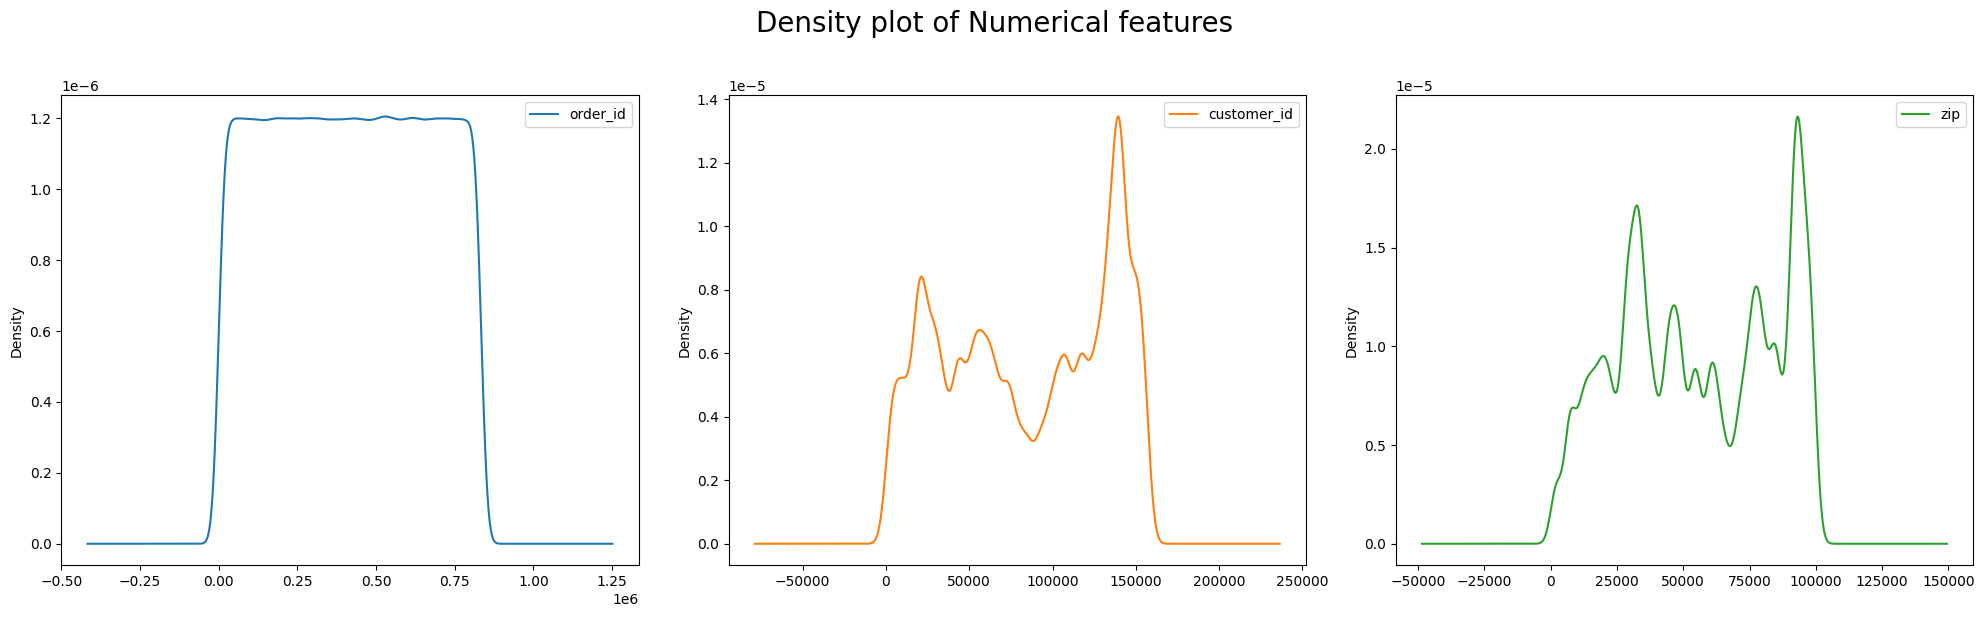

In [ ]:
distribution_analyzer_order.plot_numerical_density()

- order_id: Hình dáng gần như một hình chữ nhật phẳng (Uniform Distribution - Phân phối đều). Điều này cực kỳ hợp lý vì mã đơn hàng thường được sinh ra tăng dần theo thời gian. Nó cho thấy dữ liệu được lấy mẫu liên tục và không bị mất tập trung vào một khoảng thời gian cụ thể nào.
- customer_id: Có một đỉnh rất cao ở khoảng ID 140.000 - 150.000. Điều này ám chỉ rằng nhóm khách hàng mới (có ID cao) đang hoạt động rất tích cực hoặc có một đợt khuyến mãi lớn thu hút nhóm khách hàng này đặt hàng hàng loạt.
  - Các khoảng trũng giữa các đỉnh cho thấy có những nhóm khách hàng (theo dải ID) ít đặt hàng hơn hoặc đã ngưng hoạt động.
- zip: Đỉnh cao nhất nằm ở dải mã Zip 90.000 - 100.000. Điều này cho thấy thị trường trọng điểm của doanh nghiệp nằm ở khu vực này.


--- Boxplot ---


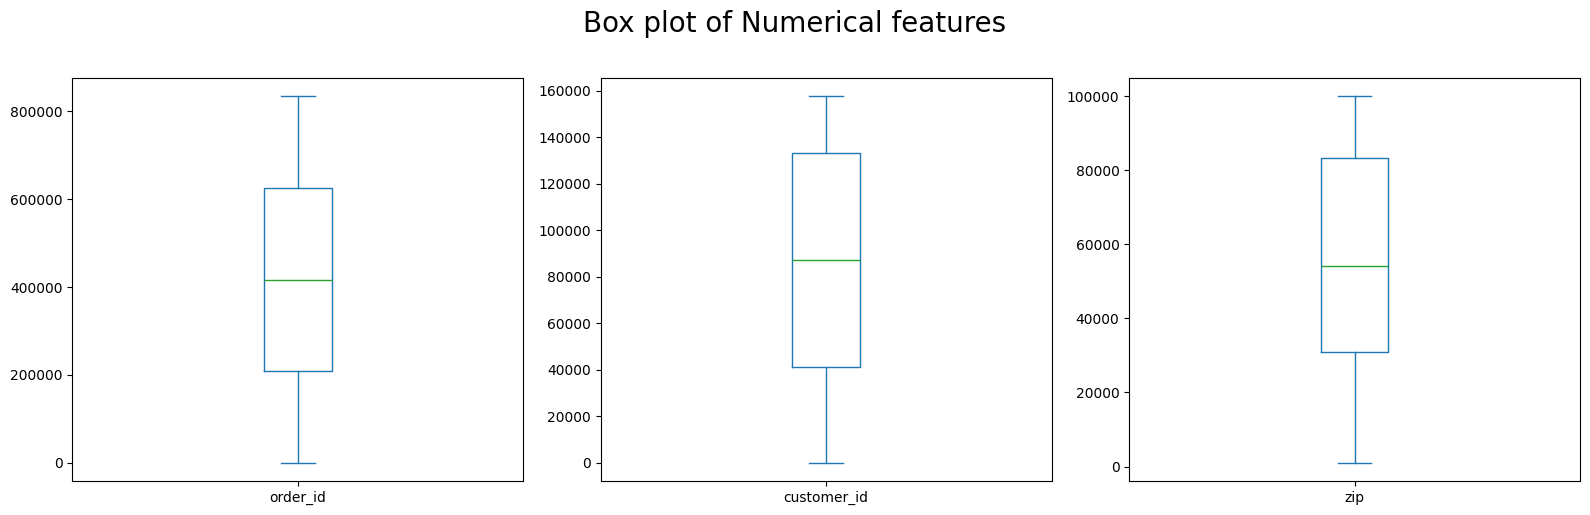

In [ ]:
distribution_analyzer_order.plot_numerical_boxplot()

Do các cột này là định danh nên để tránh Privacy problem có thể phải loại bỏ sau này.


--- Thống kê biến phân loại ---

Phân phối của order_date:
order_date
2018-05-30    0.001241
2018-05-31    0.001209
2018-06-01    0.001121
2017-03-30    0.001121
2014-04-29    0.001082
                ...   
2021-01-02    0.000026
2021-03-02    0.000022
2020-01-02    0.000020
2013-03-02    0.000014
2020-02-29    0.000012
Name: proportion, Length: 3833, dtype: float64

Phân phối của order_status:
order_status
delivered    0.798702
cancelled    0.091912
returned     0.055866
shipped      0.021289
paid         0.020986
created      0.011245
Name: proportion, dtype: float64

Phân phối của payment_method:
payment_method
credit_card      0.550823
paypal           0.149963
cod              0.149442
apple_pay        0.100106
bank_transfer    0.049666
Name: proportion, dtype: float64

Phân phối của device_type:
device_type
mobile     0.450551
desktop    0.400119
tablet     0.149330
Name: proportion, dtype: float64

Phân phối của order_source:
order_source
organic_search    0.280542
paid_search

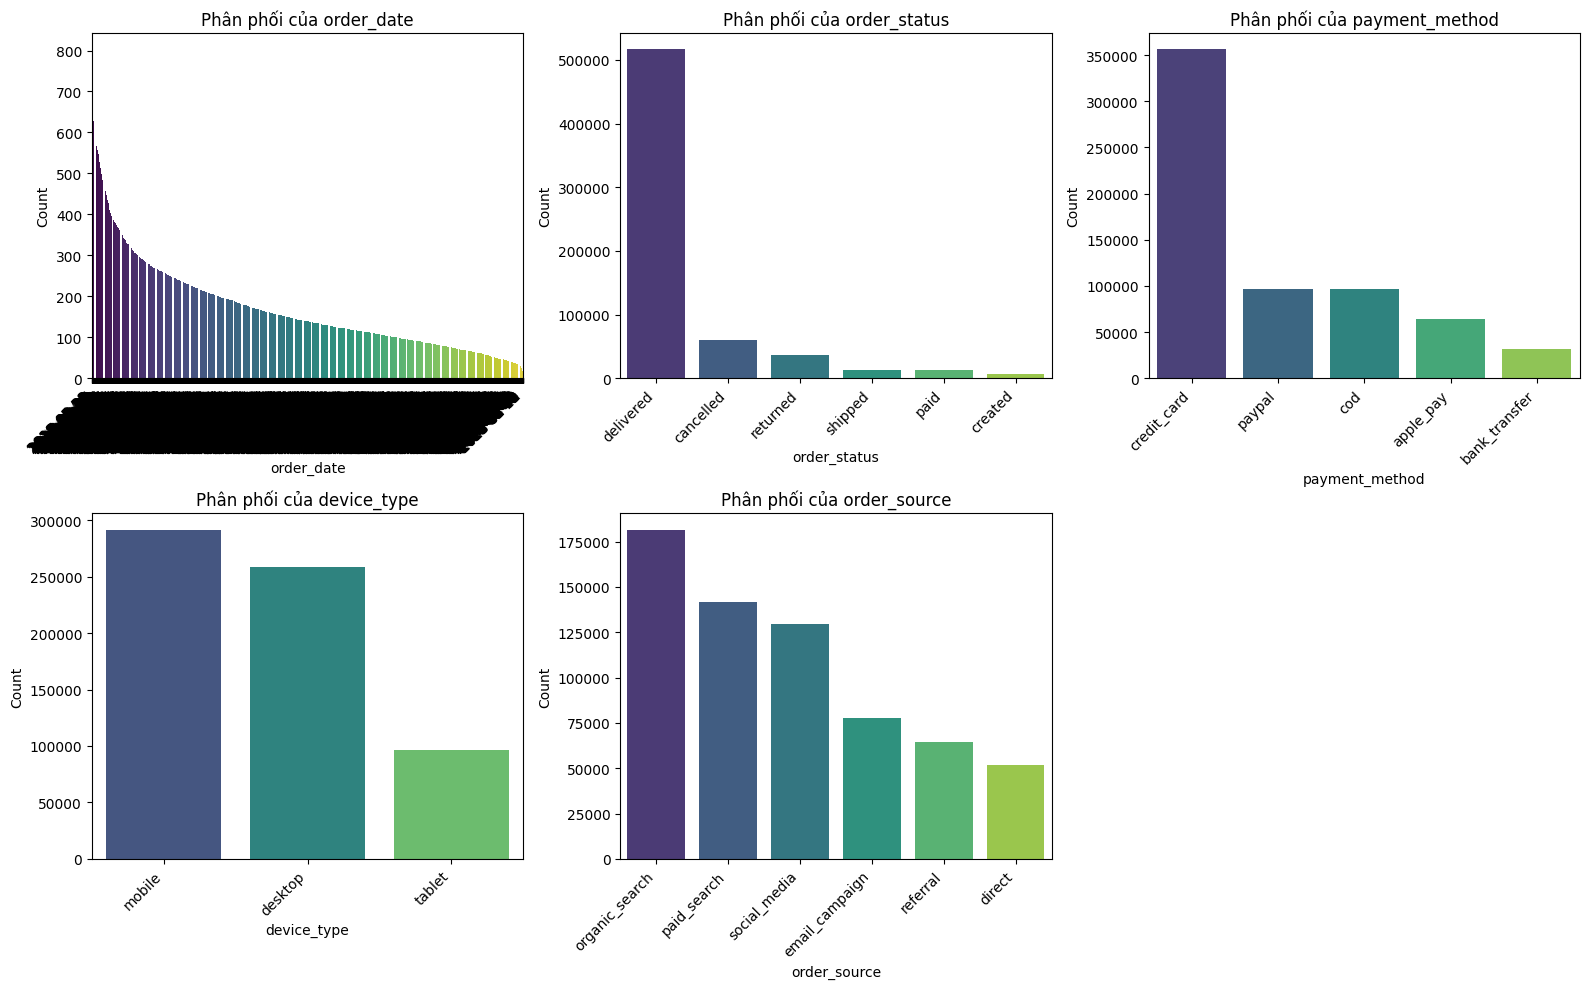

In [ ]:
distribution_analyzer_order.describe_categorical_data()
distribution_analyzer_order.plot_categorical_distribution()

- order_status:
  - Tỉ lệ giao hàng thành công (Delivered) rất cao (~80%): Đây là một dấu hiệu cực kỳ tốt, cho thấy quy trình logistics và chuỗi cung ứng của doanh nghiệp đang hoạt động ổn định.
  - Tỉ lệ Hủy đơn (Cancelled - 9.2%) và Trả hàng (Returned - 5.6%) cộng lại lên tới gần 15%.
  
  ***-> Có thể cô lập các dòng này để tìm nguyên do***
- payment_method:
  - Thẻ tín dụng (Credit Card) chiếm ưu thế tuyệt đối (55%).
  - Ví điện tử: Paypal (15%) và Apple Pay (10%) chiếm tổng cộng 25%. Điều này đòi hỏi hệ thống thanh toán trực tuyến phải luôn mượt mà.
  - Thanh toán khi nhận hàng (COD) vẫn quan trọng (15%).
- device_type:
  - Mobile (45%) vs Desktop (40%): Khoảng cách giữa di động và máy tính để bàn không quá lớn.
- order_source:
  - Tìm kiếm tự nhiên (Organic Search - 28%) dẫn đầu: Đây là tin rất vui. Doanh nghiệp đang làm SEO rất tốt, khách hàng tự tìm đến mà không tốn chi phí quảng cáo trực tiếp cho mỗi click.
  - Phụ thuộc vào quảng cáo (Paid Search & Social Media): Hai nguồn này chiếm tổng cộng 42% (22% + 20%).
  - Direct (8%) và Referral (10%) còn thấp: Tỉ lệ khách hàng tự truy cập trực tiếp vào website (Direct) chưa cao, cho thấy độ nhận diện thương hiệu (Brand Awareness) để khách hàng nhớ tên và gõ trực tiếp vào trình duyệt vẫn cần được cải thiện.


--- Ma trận tương quan và heatmap ---


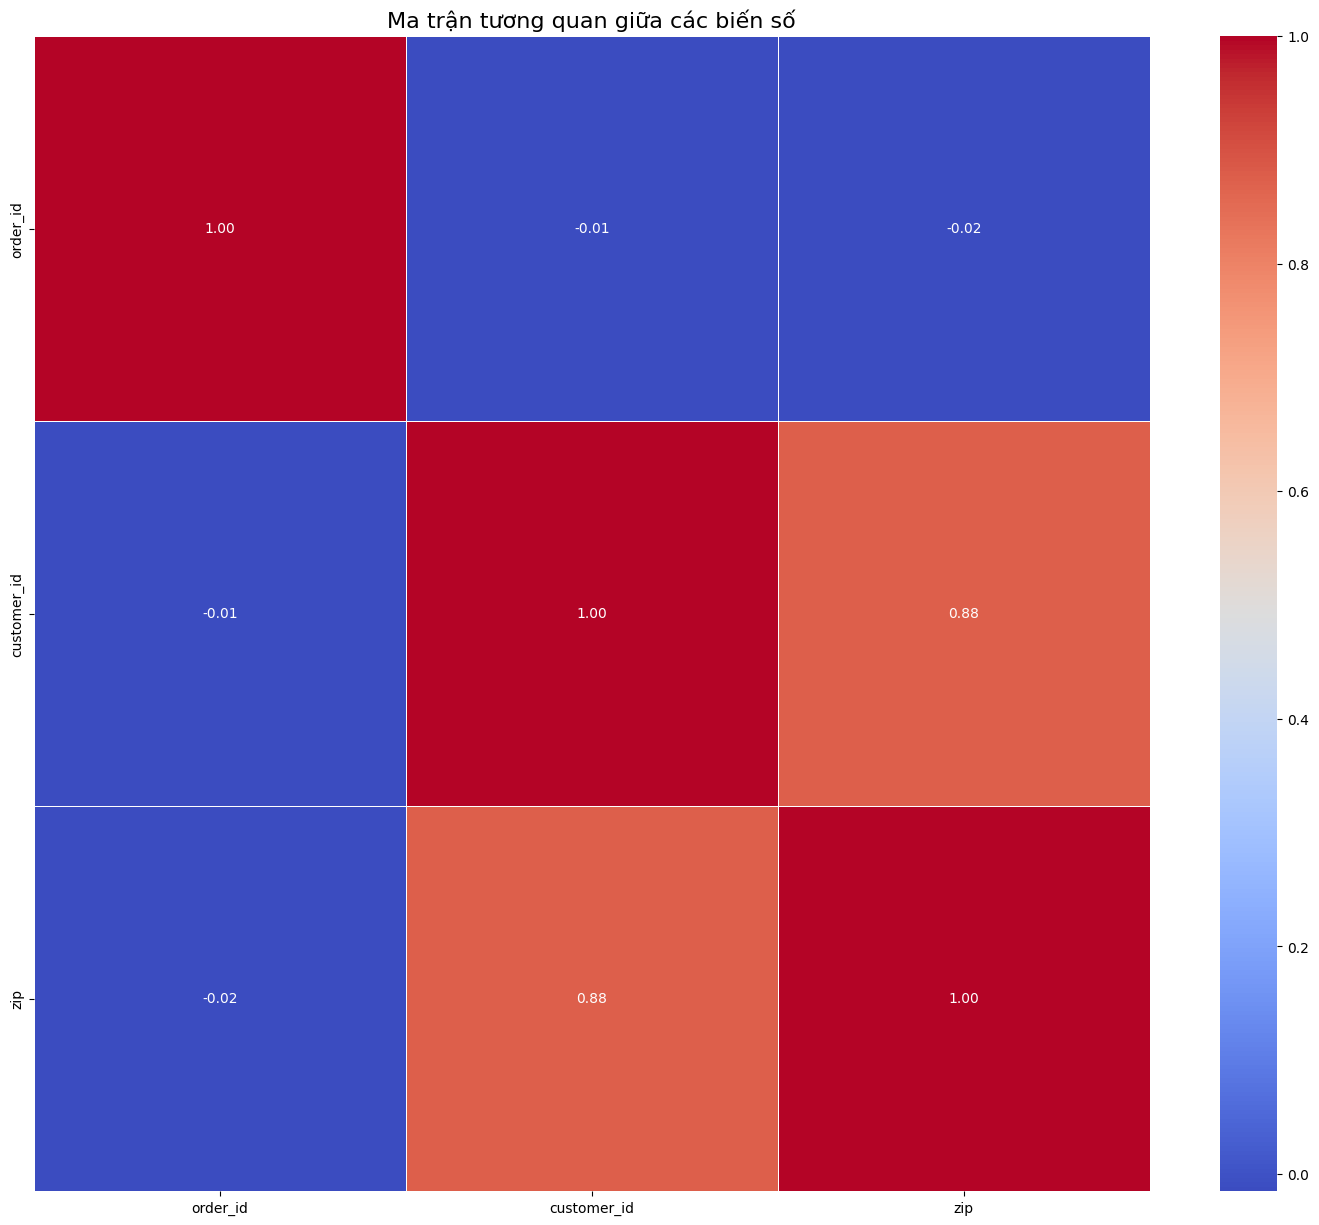

In [ ]:
correlation_analyzer_order.plot_correlation_matrix()

- Đây là điểm đáng chú ý nhất trong biểu đồ. Thông thường, mã khách hàng và mã bưu điện không nên có mối quan hệ toán học với nhau, nhưng ở đây hệ số lên tới 0.88 (tương quan thuận rất mạnh).
- Giả thuyết dưỡi góc độ kinh doanh:
  - Có thể dữ liệu khách hàng được đổ vào hệ thống hoặc được đánh mã sau khi đã sắp xếp theo khu vực địa lý.
  - Các chiến dịch quảng cáo có thể đã được triển khai cuốn chiếu từ vùng này sang vùng khác, dẫn đến việc khách hàng ở cùng một vùng địa lý sẽ đăng ký tài khoản trong cùng một khoảng thời gian và nhận được các ID gần nhau.

=> Mặc dù hệ số 0.88 là rất cao, nhưng cần nhớ rằng đây là tương quan giữa các biến định danh (Identifiers) được số hóa.

## order_items

### Tổng quan

In [ ]:
eda_order_item = EDA_classes.EDA(df=df_order_item)
distribution_analyzer_order_item = EDA_classes.DistributionAnalyzer(eda_order_item.df)
duplicate_and_null_analyzer_order_item = EDA_classes.DuplicateAndNullAnalyzer(eda_order_item.df)
correlation_analyzer_order_item = EDA_classes.CorrelationAnalyzer(eda_order_item.df)

In [ ]:
eda_order_item.df.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [ ]:
eda_order_item.display_shape()


--- Kích thước của dataframe ---
(714669, 7)


In [ ]:
eda_order_item.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer_order_item.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


In [ ]:
duplicate_and_null_analyzer_order_item.missing_check()


--- Kiểm tra dữ liệu thiếu ---
order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64


- promo_id: Những dòng trống này đại diện cho các sản phẩm được bán theo giá gốc hoặc không áp dụng mã giảm giá chính.
- promo_id_2: Số lượng trống ở đây cao hơn nhiều so với promo_id. Điều này cho thấy chiến lược "Cộng dồn khuyến mãi" (Stacking Promos) rất ít khi xảy ra. Đa số khách hàng chỉ áp dụng 1 mã, và rất ít người (hoặc rất ít đợt chiến dịch) cho phép áp dụng đến mã thứ 2.
- Mặc dù promo_id trống rất nhiều, nhưng cột discount_amount lại không có giá trị thiếu.
  - Điều này đặt ra một câu hỏi cần kiểm tra (Actionable Insight):
    - Tại các dòng mà promo_id bị NULL, thì discount_amount có bằng 0 hay không?
    - Nếu promo_id NULL mà discount_amount vẫn lớn hơn 0, có thể hệ thống đang áp dụng "Giảm giá trực tiếp trên giá sản phẩm" (Price Markdown) thay vì dùng "Mã giảm giá" (Coupon).

=> Có thể điền giá trị thay thế (Imputation): Bạn nên điền các giá trị NULL ở promo_id và promo_id_2 bằng một nhãn như 'NO_PROMO' hoặc 'NONE' để khi vẽ biểu đồ hoặc đưa vào mô hình máy học, hệ thống sẽ hiểu đó là một nhóm khách hàng mua hàng không cần khuyến mãi.

In [ ]:
cols_with_missing = ['promo_id', 'promo_id_2']
duplicate_and_null_analyzer_order_item.all_empty(cols_with_missing)


--- Kiểm tra trống đồng bộ trên: promo_id, promo_id_2 ---
Tìm thấy 438353 dòng trống đồng bộ:


Ta thấy toàn bộ promo_id null thì promo_id_2 cũng null có thể do không có cộng dồn khuyến mãi.
-  Nếu muốn xây dựng mô hình dự báo xem khách hàng có dùng mã hay không, bạn chỉ cần dự báo cho cột promo_id. Nếu promo_id là không (None), thì mặc nhiên promo_id_2 cũng là không.

In [ ]:
duplicate_and_null_analyzer_order_item.null_analyze(['promo_id'])


=== PHÂN TÍCH GIÁ TRỊ THIẾU ===
Phân tích: ['promo_id']

--- Cột: promo_id ---
Số hàng chỉ thiếu 'promo_id': 0


In [ ]:
duplicate_and_null_analyzer_order_item.null_analyze(['promo_id_2'])


=== PHÂN TÍCH GIÁ TRỊ THIẾU ===
Phân tích: ['promo_id_2']

--- Cột: promo_id_2 ---
Số hàng chỉ thiếu 'promo_id_2': 276110

Sai số tương đối (mean/median/var):
        order_id  unit_price  product_id  discount_amount  quantity
mean    0.093630   -0.414865    0.200376        -0.127542  0.109026
median  0.360952   -0.511561    0.486364        -0.399052  0.250000
var     4.088580    0.061867   -0.046534         0.795837  0.096317


- unit_price: Những sản phẩm chỉ dùng 1 mã có đơn giá thấp hơn khoảng 40-50% so với sản phẩm dùng 2 mã.
  - Việc "cộng dồn mã" (Double-Promo) chủ yếu xảy ra ở các sản phẩm giá trị cao. Có khả năng doanh nghiệp chỉ cho phép áp dụng thêm mã thứ hai để kích cầu cho các mặt hàng đắt tiền, khó bán. Các mặt hàng giá rẻ vốn dĩ đã dễ tiếp cận nên thường chỉ áp dụng tối đa 1 mã.
- product_id: Nhóm chỉ dùng 1 mã thường rơi vào các sản phẩm có mã ID cao hơn, có vẻ như các sản phẩm mới (ID cao) đang được áp dụng chiến sách "chỉ 1 mã giảm giá", trong khi các sản phẩm cũ hoặc dòng sản phẩm đặc biệt mới được áp dụng chương trình cộng dồn mã.

=> Dự đoán:
  - Chiến lược 2 mã (Double-Promo): Dùng để "đẩy hàng" giá trị cao, tập trung vào các sự kiện mua sắm lớn, đánh vào tâm lý khách hàng muốn giảm giá sâu trên những món đồ đắt tiền.
  - Chiến lược 1 mã (Single-Promo): Áp dụng cho các sản phẩm phổ thông, giá rẻ, khách hàng có xu hướng mua số lượng nhiều (bulk-buying).

***-> Có thể cần phải mapping (thay null = no_promo hoặc 0/1) trước khi phân tích sâu hơn***

### Phân phối của dữ liệu

In [ ]:
distribution_analyzer_order_item.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
            order_id     product_id       quantity     unit_price  \
count  714669.000000  714669.000000  714669.000000  714669.000000   
mean   411615.076561    1234.931370       4.495988    5114.690157   
std    240480.310686     691.332564       2.290143    3774.817912   
min         1.000000       1.000000       1.000000     392.570000   
25%    203229.000000     689.000000       2.000000    1906.890000   
50%    409306.000000     990.000000       4.000000    4257.770000   
75%    618981.000000    2045.000000       6.000000    7273.760000   
max    834397.000000    2412.000000       8.000000   43056.000000   

       discount_amount  
count    714669.000000  
mean       1048.887415  
std        2280.530606  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%         967.630000  
max       35235.470000  


- quantity: Mặc dù mỗi đơn hàng ít loại sản phẩm, nhưng khách hàng lại mua số lượng lớn cho mỗi loại (trung bình mua 4-5 cái cùng lúc).


--- Biểu đồ mật độ ---


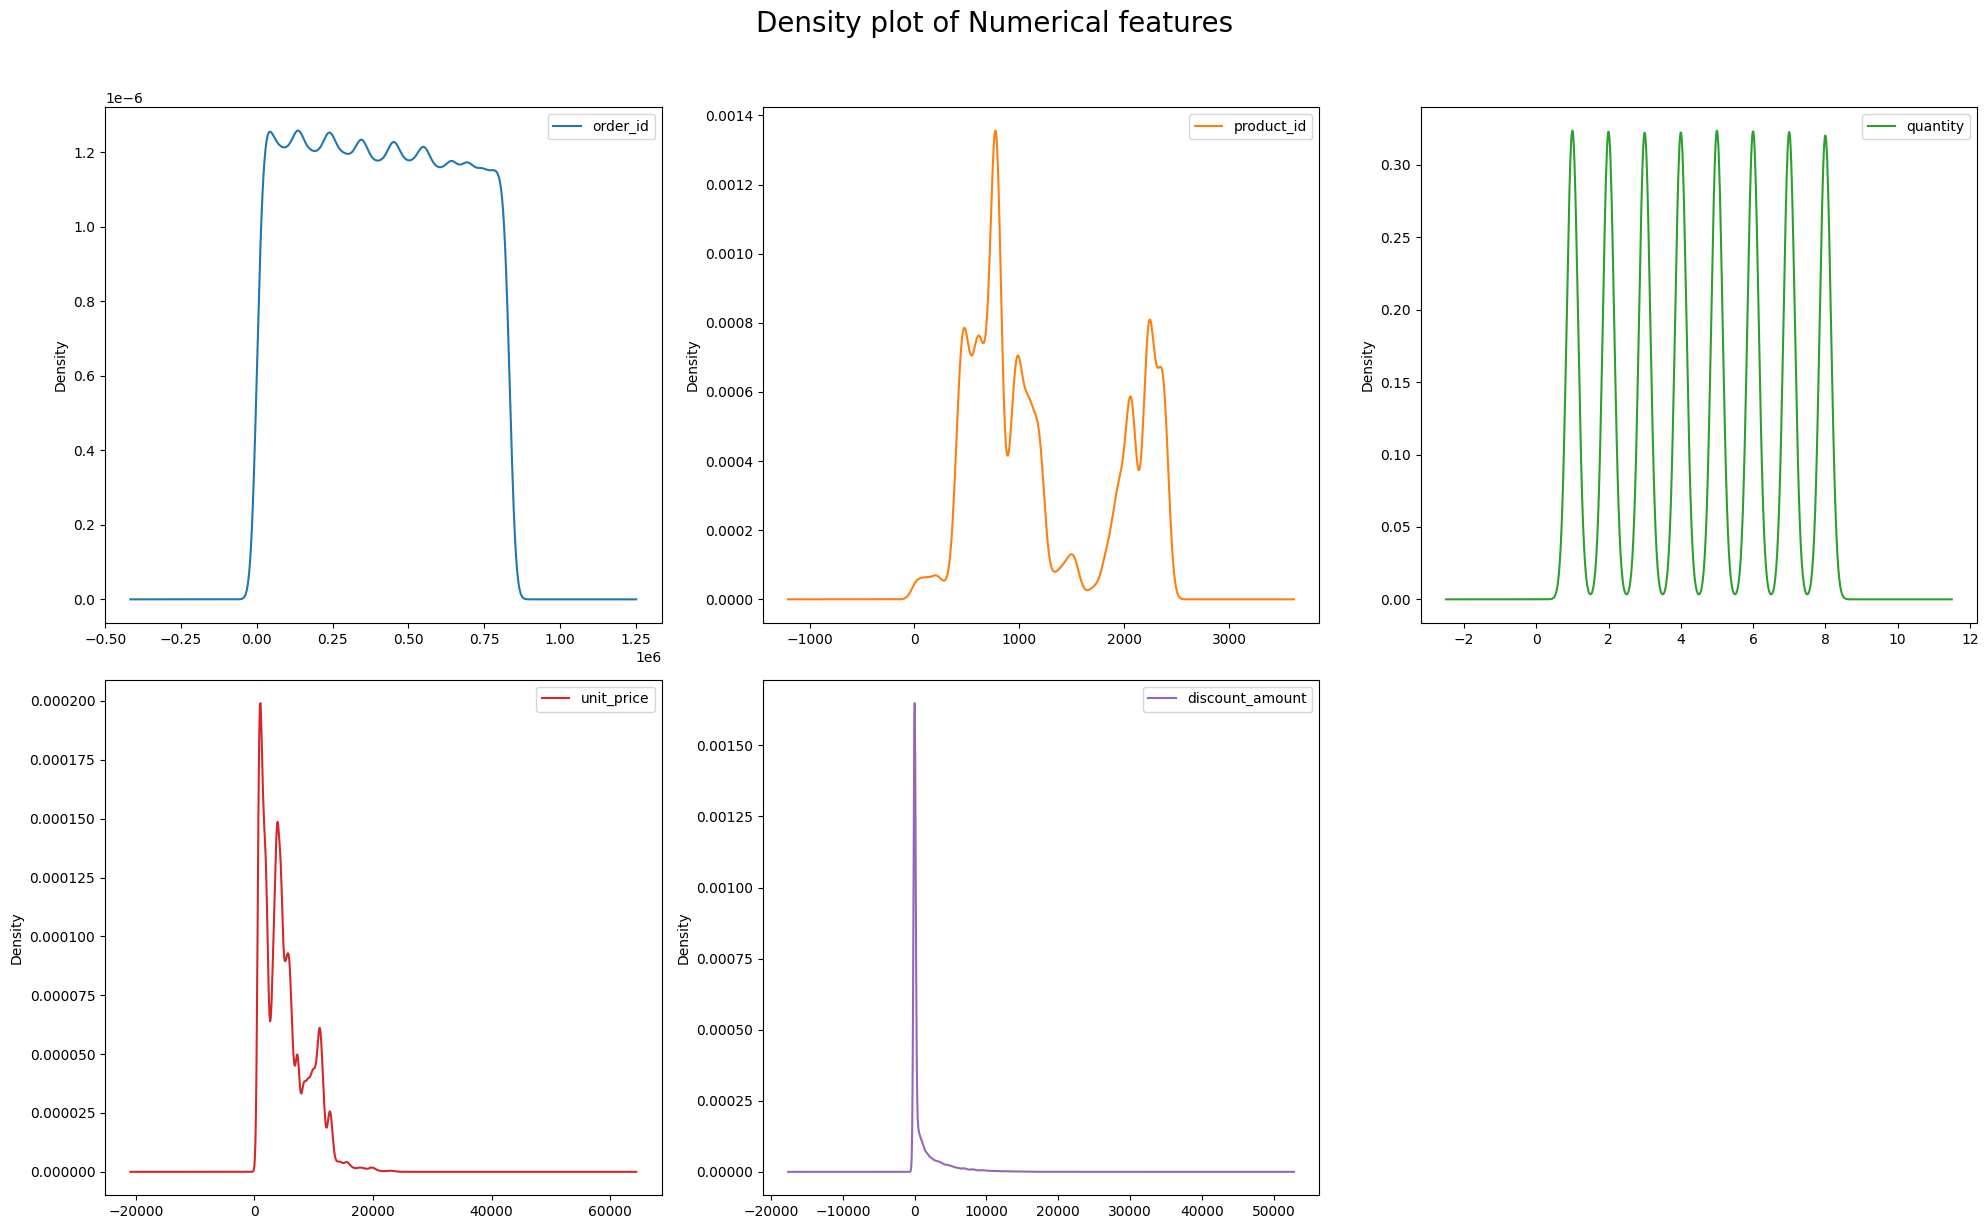

In [ ]:
distribution_analyzer_order_item.plot_numerical_density()

- quantity: Khách hàng đặt mua số lượng rất đồng đều, không có đơn hàng nào mua số lượng đột biến.
- product_id: Có 2 nhóm đỉnh rất rõ rệt: nhóm quanh mã 800-1000 và nhóm quanh mã 2000-2300.
- unit_price:  Lệch phải cực mạnh (Right-skewed). Đỉnh cao nhất nằm ở mức giá thấp (dưới 5.000), sau đó giảm dần nhưng kéo dài mãi đến hơn 40.000.
- discount_amount: Một cột đứng sát vạch 0, cho thấy đa số dòng hàng không được giảm giá (như đã phân tích ở bảng thống kê trước).


--- Boxplot ---


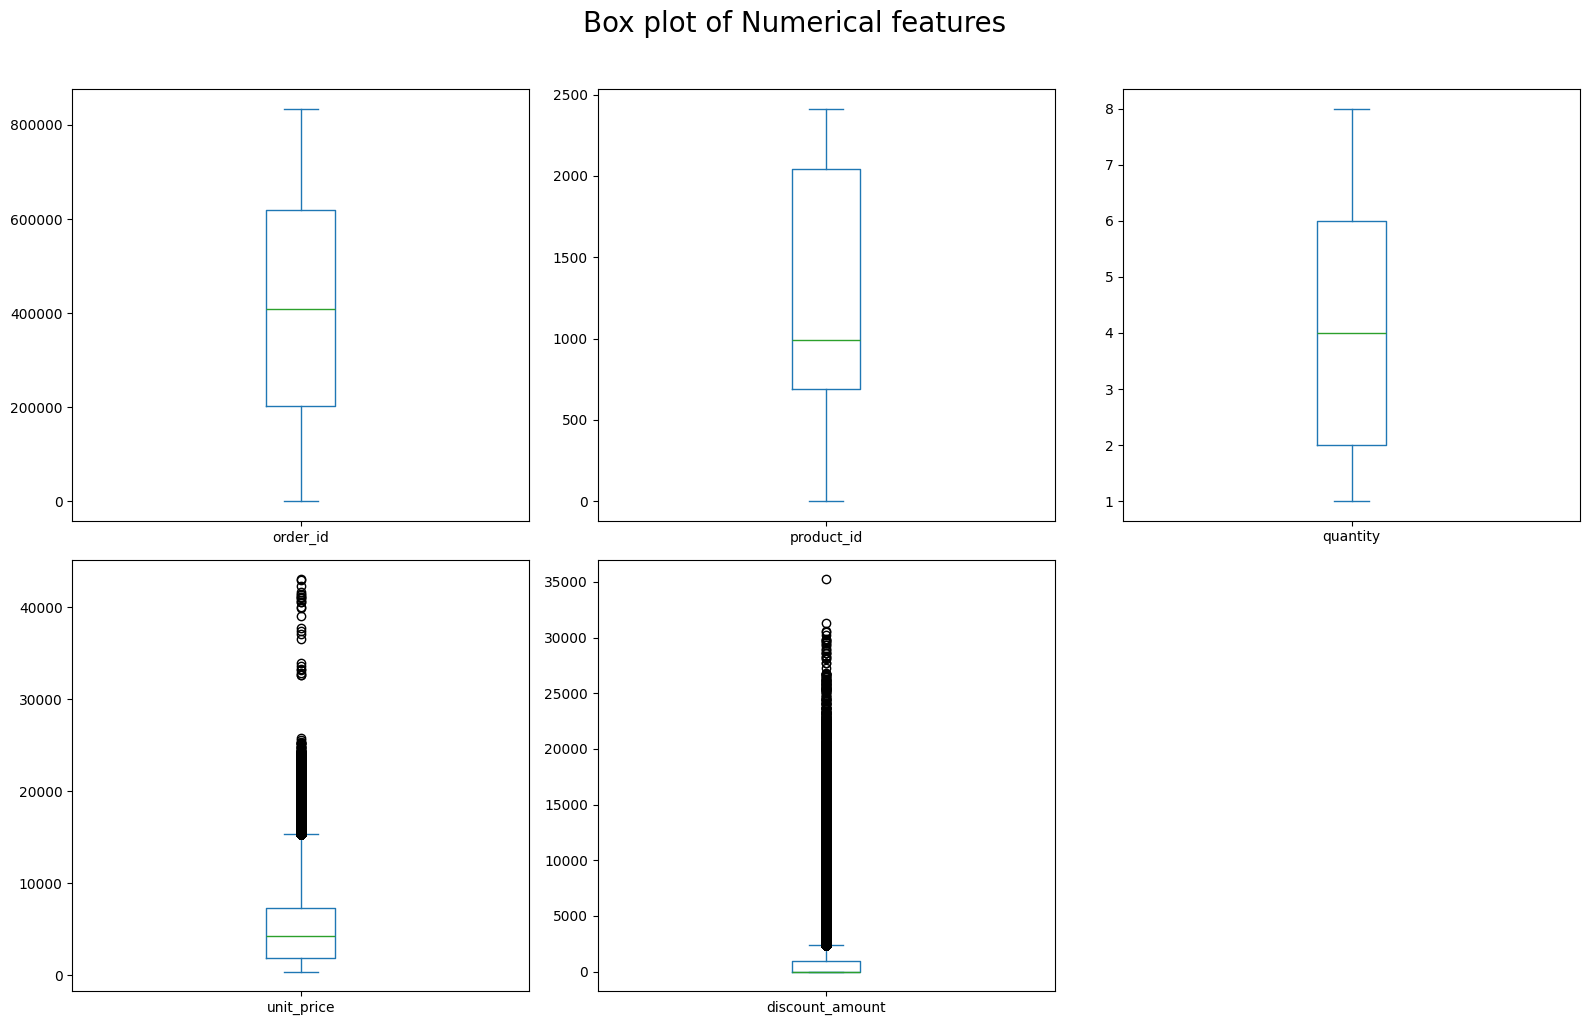

In [ ]:
distribution_analyzer_order_item.plot_numerical_boxplot()

- unit_price: Xuất hiện rất nhiều giá trị ngoại lai (outliers) phía trên mức 15.000. Mặc dù đa số mặt hàng có giá bình dân, doanh nghiệp vẫn có một nhóm sản phẩm "Luxury" hoặc thiết bị đặc biệt có giá cao vọt hẳn lên. Những sản phẩm này tuy ít nhưng sẽ đóng góp lớn vào tổng doanh thu.
- discount_amount: Mật độ ngoại lai dày đặc. Hầu như bất kỳ giá trị giảm giá nào đáng kể (trên khoảng 2.000) đều bị coi là ngoại lai so với phần lớn dữ liệu (vốn bằng 0).


--- Thống kê biến phân loại ---

Phân phối của promo_id:
promo_id
NaN           0.613365
PROMO-0014    0.016023
PROMO-0010    0.015874
PROMO-0004    0.015568
PROMO-0020    0.014162
PROMO-0011    0.013424
PROMO-0007    0.013115
PROMO-0021    0.012546
PROMO-0017    0.012325
PROMO-0001    0.011926
PROMO-0024    0.011481
PROMO-0028    0.011398
PROMO-0002    0.010850
PROMO-0027    0.010520
PROMO-0022    0.010503
PROMO-0013    0.010492
PROMO-0018    0.009919
PROMO-0008    0.009919
PROMO-0012    0.009518
PROMO-0003    0.008783
PROMO-0019    0.008064
PROMO-0009    0.007888
PROMO-0023    0.007574
PROMO-0025    0.007535
PROMO-0015    0.007097
PROMO-0030    0.007033
PROMO-0005    0.006838
PROMO-0047    0.006704
PROMO-0031    0.006602
PROMO-0037    0.006522
PROMO-0041    0.006491
PROMO-0029    0.006056
PROMO-0034    0.005985
PROMO-0032    0.005411
PROMO-0050    0.004897
PROMO-0044    0.004844
PROMO-0040    0.004598
PROMO-0035    0.004441
PROMO-0033    0.004339
PROMO-0048    0.004325
PROMO-0038   

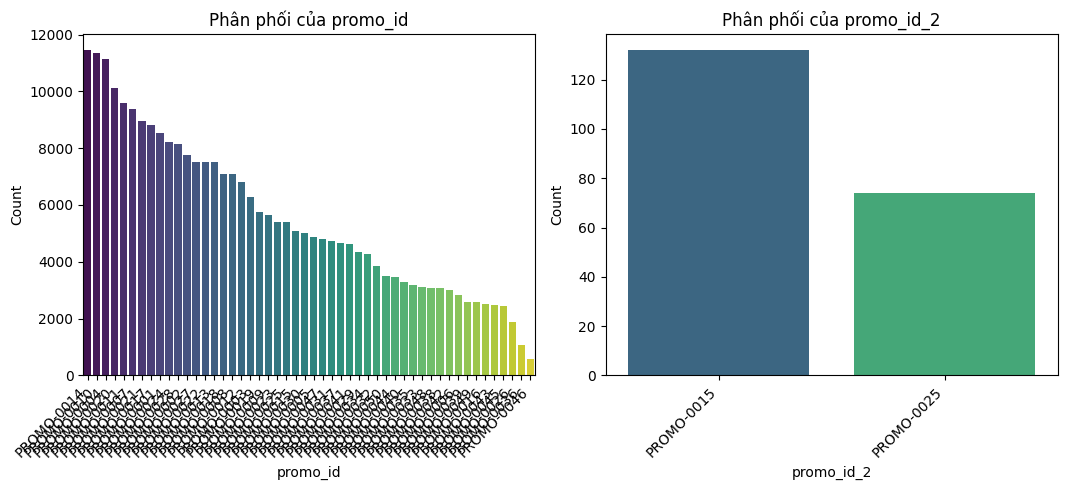

In [ ]:
distribution_analyzer_order_item.describe_categorical_data()
distribution_analyzer_order_item.plot_categorical_distribution()

- Có tới 50 mã khuyến mãi khác nhau (từ PROMO-0001 đến PROMO-0050). Không có mã nào chiếm tỷ lệ áp đảo. Các mã phổ biến nhất như PROMO-0014, PROMO-0010, PROMO-0004 cũng chỉ chiếm khoảng 1.5% - 1.6% tổng lượng hàng bán ra.
- Chỉ có khoảng 0.03% đơn hàng (tương đương khoảng hơn 200 dòng trong tổng số hơn 714k dòng) là có áp dụng mã thứ hai.
  - Cột promo_id_2 trong database có thể là một tính năng cũ hoặc chỉ dành cho những trường hợp cực kỳ đặc biệt (như đền bù cho khách hàng VIP hoặc lỗi hệ thống). Bạn có thể loại bỏ cột này khỏi các mô hình dự báo vì nó quá ít dữ liệu (noise).

***-> Có thể lọc ra tệp khách hàng đặc biệt này (tiềm năng)***


--- Ma trận tương quan và heatmap ---


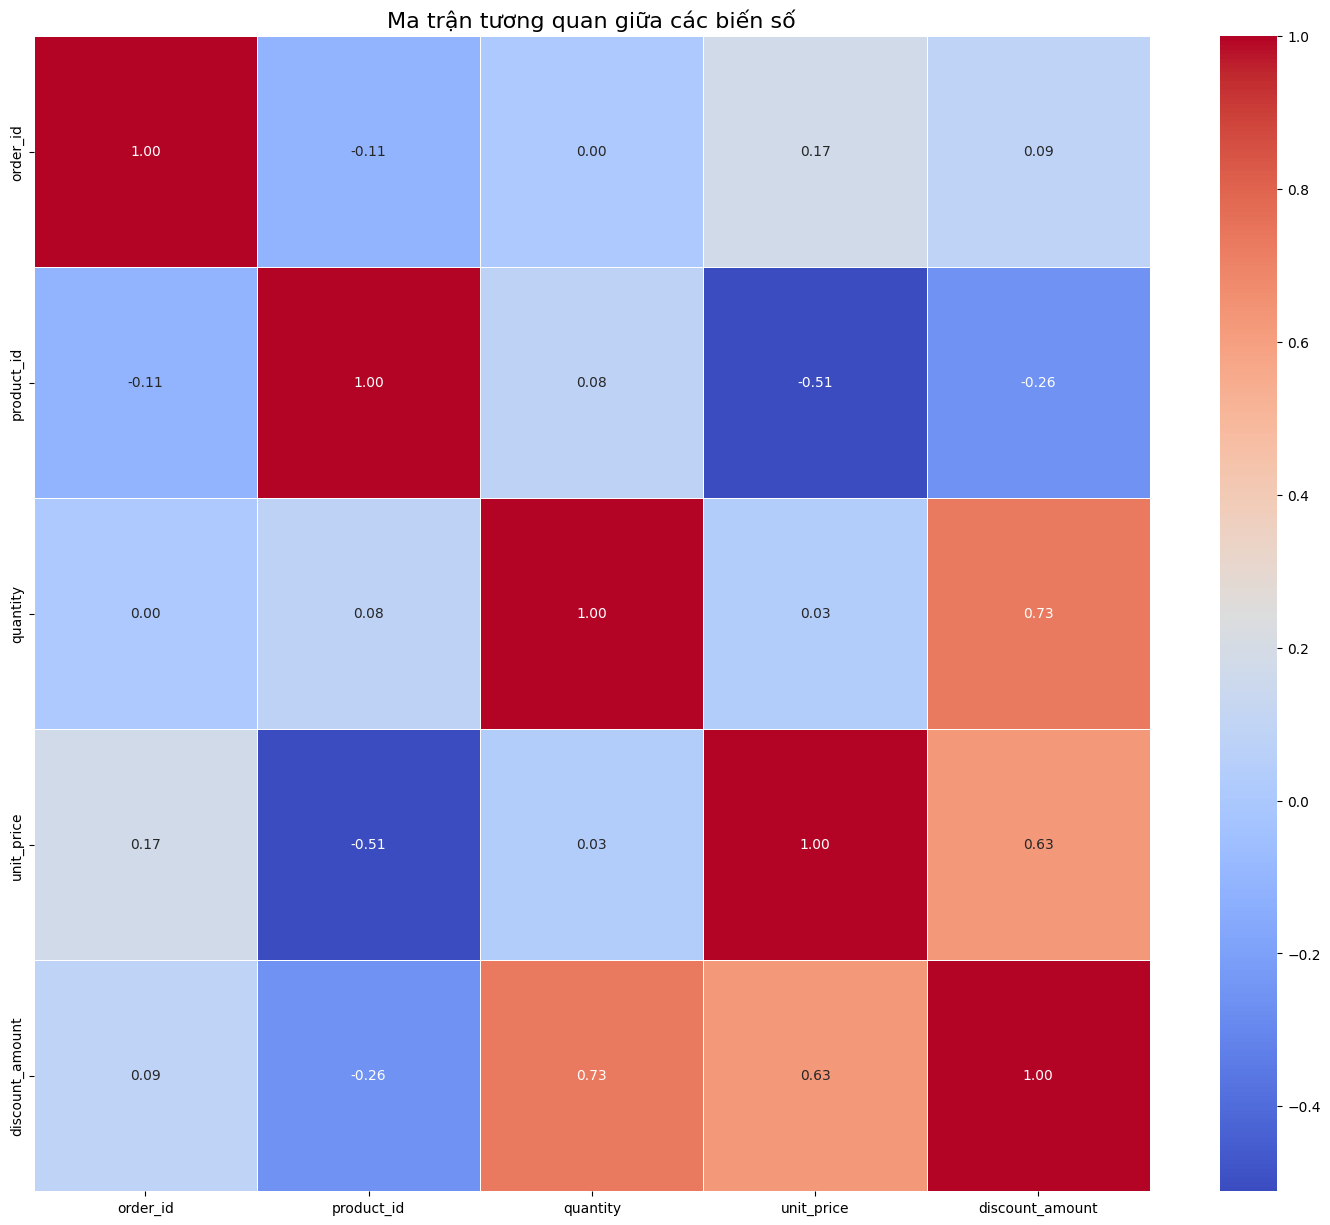

In [ ]:
correlation_analyzer_order_item.plot_correlation_matrix()

- Mối quan hệ giữa quantity và discount_amount (0.73) - Tương quan mạnh nhất: Số lượng sản phẩm mua càng nhiều thì số tiền giảm giá càng lớn.
- Mối tương quan giữa unit_price và discount_amount (0.63): Những sản phẩm có đơn giá càng cao thì số tiền được giảm giá càng lớn.
- Mối tương quan nghịch giữa product_id và unit_price (-0.51): Có thể các sản phẩm đời đầu (ID thấp) là các mặt hàng chủ lực, máy móc hoặc thiết bị đắt tiền. Các sản phẩm mới được thêm vào hệ thống sau này (ID cao) có thể là các mặt hàng tiêu dùng, phụ kiện hoặc sản phẩm phân khúc bình dân hơn.

## geography

### Tổng quan

In [ ]:
eda_unit = EDA(df = geography)
duplicate_and_null_analyzer = DuplicateAndNullAnalyzer(eda_unit.df)   # Kiểm tra trùng lặp và null
distribution_analyzer = DistributionAnalyzer(eda_unit.df)   # Kiểm tra phân phối

In [ ]:
eda_unit.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [ ]:
eda_unit.display_dataframe()


--- DataFrame ---


,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13
...,...,...,...,...
39943,59933,Pleiku,West,District #33
39944,59934,Soc Trang,West,District #33
39945,59935,Rach Gia,West,District #33
39946,59936,Vung Tau,West,District #33


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


In [ ]:
duplicate_and_null_analyzer.missing_check()


--- Kiểm tra dữ liệu thiếu ---
zip         0
city        0
region      0
district    0
dtype: int64


In [ ]:
distribution_analyzer.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
                zip
count  39948.000000
mean   50895.084735
std    27042.257341
min        1.000000
25%    28279.500000
50%    49876.500000
75%    73526.250000
max    99950.000000


In [ ]:
distribution_analyzer.describe_categorical_data()


--- Thống kê biến phân loại ---

Phân phối của city:
city
Cam Pha                0.035121
Phu Ly                 0.035021
Thai Nguyen            0.034895
Hanoi                  0.034445
Nam Dinh               0.034295
Ha Long                0.033969
Bac Giang              0.033719
Hai Phong              0.033694
Bac Ninh               0.033694
Son Tay                0.033644
Ninh Binh              0.033193
Uong Bi                0.033168
Viet Tri               0.033143
Lao Cai                0.031841
Kon Tum                0.031666
Hoi An                 0.031416
Dong Hoi               0.031191
Phan Rang-Thap Cham    0.030515
Hue                    0.030440
Tuy Hoa                0.030339
Nha Trang              0.030014
Quang Ngai             0.029839
Phan Thiet             0.029764
Tam Ky                 0.029538
Da Nang                0.029338
Quy Nhon               0.029213
Ho Chi Minh City       0.011415
Vinh Long              0.010789
Vung Tau               0.010489
Ca Mau       

### Phân phối của dữ liệu


--- Phân phối cho biến phân loại ---


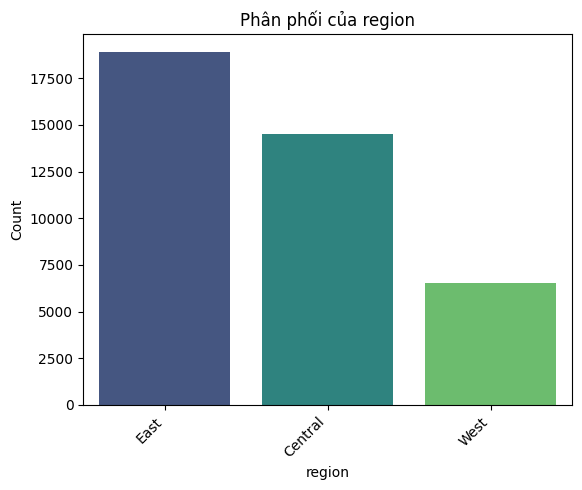

In [ ]:
distribution_analyzer.plot_categorical_distribution(cols=['region'])

In [ ]:
# Kiểm tra mapping zip-code -> city (mỗi city tương ứng với 1 zipcode duy nhất)
zip_city_mapping = geography.groupby('zip')['city'].nunique()
non_unique_zip_cities = zip_city_mapping[zip_city_mapping > 1]

if not non_unique_zip_cities.empty:
    print("Các mã zip-code không ánh xạ duy nhất đến một thành phố:")
    for zip_code in non_unique_zip_cities.index:
        cities = geography[geography['zip'] == zip_code]['city'].unique()
        print(f"  Zip code {zip_code} ánh xạ đến các thành phố: {', '.join(cities)}")
else:
    print("Mỗi mã zip-code ánh xạ duy nhất đến một thành phố.")

Mỗi mã zip-code ánh xạ duy nhất đến một thành phố.


## reviews

### Tổng quan

In [ ]:
eda_unit = EDA(df = reviews)
duplicate_and_null_analyzer = DuplicateAndNullAnalyzer(eda_unit.df)   # Kiểm tra trùng lặp và null
distribution_analyzer = DistributionAnalyzer(eda_unit.df)   # Kiểm tra phân phối

In [ ]:
eda_unit.display_dataframe()


--- DataFrame ---


,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall
...,...,...,...,...,...,...,...
113546,REV-0146937,833044,452,133643,2022-12-31,4,Happy with purchase
113547,REV-0146943,833081,2224,37745,2022-12-31,5,Excellent product!
113548,REV-0146946,833094,2197,62534,2022-12-27,1,Not as described
113549,REV-0146948,833108,407,17298,2022-12-30,4,Works well


In [ ]:
eda_unit.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   review_id     113551 non-null  object
 1   order_id      113551 non-null  int64 
 2   product_id    113551 non-null  int64 
 3   customer_id   113551 non-null  int64 
 4   review_date   113551 non-null  object
 5   rating        113551 non-null  int64 
 6   review_title  113551 non-null  object
dtypes: int64(4), object(3)
memory usage: 6.1+ MB


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


In [ ]:
reviews[reviews[['order_id', 'customer_id']].duplicated(keep=False)].sort_values(by='order_id')

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
31,REV-0000043,244,2252,5167,2012-08-05,5,Very satisfied
32,REV-0000044,244,2253,5167,2012-07-18,5,Very satisfied
79,REV-0000110,593,769,139497,2012-07-17,1,Very disappointed
80,REV-0000111,593,770,139497,2012-08-10,1,Poor quality
81,REV-0000113,598,739,152585,2012-07-26,4,Works well
...,...,...,...,...,...,...,...
113375,REV-0146504,830507,2262,27637,2022-12-23,5,Great quality
113468,REV-0146638,831377,2225,61439,2022-12-18,5,Great quality
113467,REV-0146637,831377,2224,61439,2022-12-12,5,Very satisfied
113469,REV-0146640,831403,791,79091,2022-12-09,5,Great quality


In [ ]:
reviews[reviews[['review_id', 'order_id', 'customer_id']].duplicated(keep=False)].sort_values(by='order_id')

,review_id,order_id,product_id,customer_id,review_date,rating,review_title


1 order cùng 1 customer có nhiều review khác nhau (khác nhau về id) không bất thường -> Có thể user chỉnh sửa review nhiều lần.

### Phân phối của dữ liệu

In [ ]:
distribution_analyzer.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
            order_id     product_id    customer_id         rating
count  113551.000000  113551.000000  113551.000000  113551.000000
mean   408999.519740    1232.018705   85694.342762       3.936011
std    239021.922809     690.839232   48501.480918       1.149867
min         1.000000       3.000000       2.000000       1.000000
25%    202048.500000     689.000000   42096.000000       3.000000
50%    406841.000000     981.000000   89755.000000       4.000000
75%    614844.000000    2045.000000  133850.000000       5.000000
max    833296.000000    2412.000000  157563.000000       5.000000


In [ ]:
distribution_analyzer.describe_categorical_data()


--- Thống kê biến phân loại ---

Phân phối của review_id:
review_id
REV-0146984    0.000009
REV-0000001    0.000009
REV-0000002    0.000009
REV-0000003    0.000009
REV-0000005    0.000009
                 ...   
REV-0000026    0.000009
REV-0000025    0.000009
REV-0000024    0.000009
REV-0000023    0.000009
REV-0000022    0.000009
Name: proportion, Length: 113551, dtype: float64

Phân phối của review_date:
review_date
2017-05-06    0.000678
2014-05-11    0.000669
2017-06-19    0.000669
2017-06-14    0.000669
2015-05-10    0.000660
                ...   
2022-02-23    0.000018
2012-07-13    0.000018
2012-07-14    0.000018
2012-07-12    0.000009
2012-07-10    0.000009
Name: proportion, Length: 3825, dtype: float64

Phân phối của review_title:
review_title
Very satisfied             0.100836
Highly recommend           0.100457
Great quality              0.098793
Excellent product!         0.098467
Good overall               0.080889
Happy with purchase        0.080765
Solid choice        


--- Biểu đồ mật độ ---


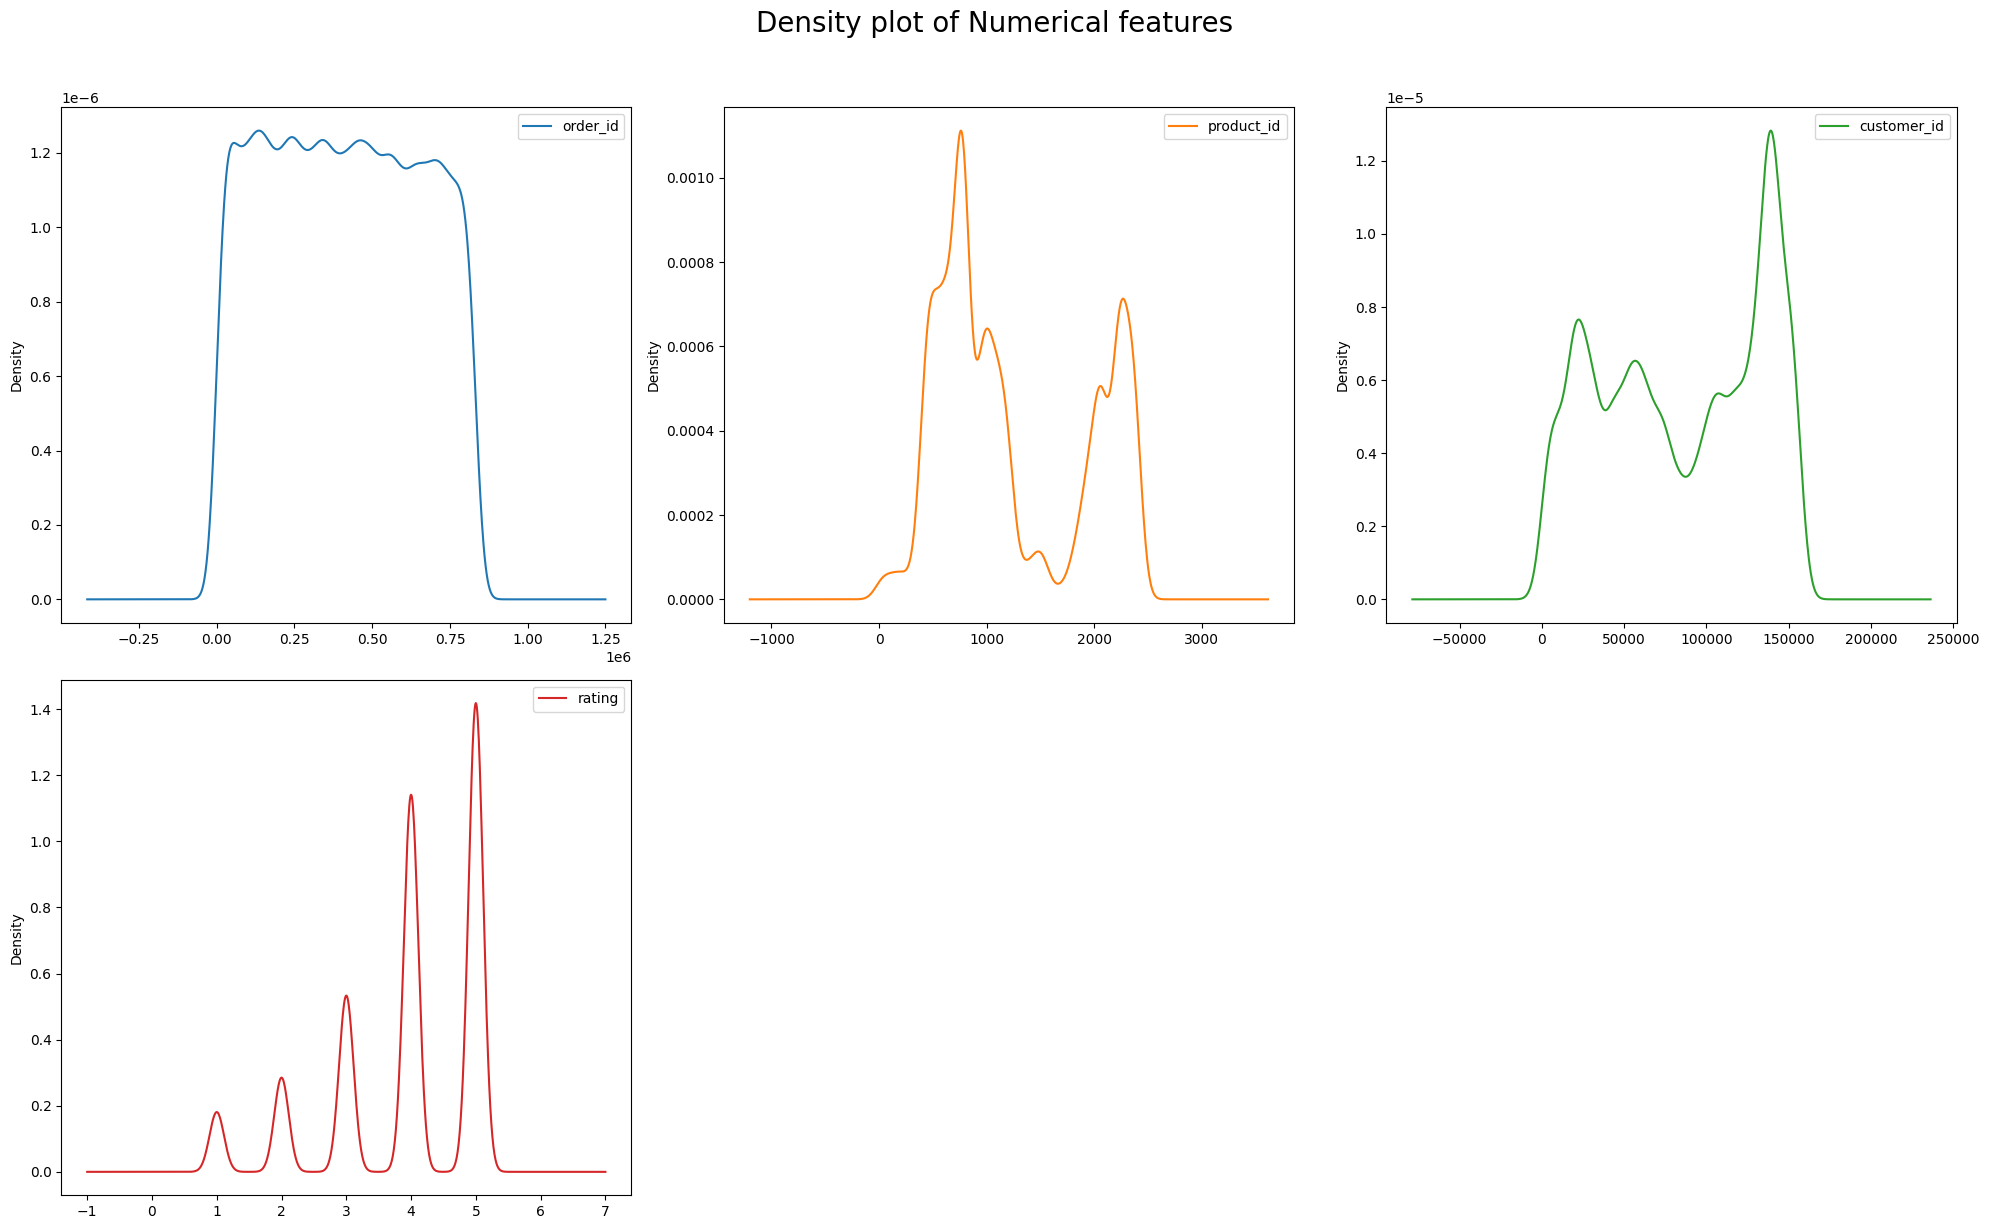

In [ ]:
distribution_analyzer.plot_numerical_density()

Nhận xét chung: mức độ hài lòng của khách hàng trong bộ dữ liệu này tương đối cao.

In [ ]:
review_id_length = []
for review_id in reviews['review_id']:
  if len(review_id) not in review_id_length:
    review_id_length.append(len(review_id))
print(f'Độ dài review_id trung bình: {np.mean(review_id_length)}')
print(f'Danh sách độ dài review_id: {review_id_length}')

Độ dài review_id trung bình: 11.0
Danh sách độ dài review_id: [11]


## customer

### Tổng quan

In [ ]:
eda_unit = EDA(df = customers)
duplicate_and_null_analyzer = DuplicateAndNullAnalyzer(eda_unit.df)   # Kiểm tra trùng lặp và null
distribution_analyzer = DistributionAnalyzer(eda_unit.df)   # Kiểm tra phân phối

In [ ]:
eda_unit.display_dataframe()


--- DataFrame ---


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


In [ ]:
eda_unit.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


### Phân phối của dữ liệu

In [ ]:
distribution_analyzer.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
         customer_id            zip
count  121930.000000  121930.000000
mean    78736.898663   50990.165595
std     45492.202886   26871.914605
min         1.000000    1001.000000
25%     39343.500000   28689.250000
50%     78784.500000   49835.000000
75%    118156.750000   73488.000000
max    157563.000000   99950.000000


In [ ]:
distribution_analyzer.describe_categorical_data()


--- Thống kê biến phân loại ---

Phân phối của city:
city
Cam Pha                0.036070
Thai Nguyen            0.035652
Phu Ly                 0.034799
Hanoi                  0.034774
Ha Long                0.034741
Bac Ninh               0.034216
Hai Phong              0.034200
Nam Dinh               0.034192
Bac Giang              0.034118
Ninh Binh              0.033470
Son Tay                0.033421
Viet Tri               0.033249
Uong Bi                0.033019
Dong Hoi               0.032084
Kon Tum                0.031477
Lao Cai                0.031223
Hoi An                 0.030837
Phan Thiet             0.030747
Phan Rang-Thap Cham    0.030624
Hue                    0.030501
Tuy Hoa                0.030132
Quang Ngai             0.029656
Da Nang                0.029656
Tam Ky                 0.029213
Quy Nhon               0.029164
Nha Trang              0.029115
Ho Chi Minh City       0.011146
Vinh Long              0.010957
Pleiku                 0.010276
Vung Tau     


--- Phân phối cho biến phân loại ---


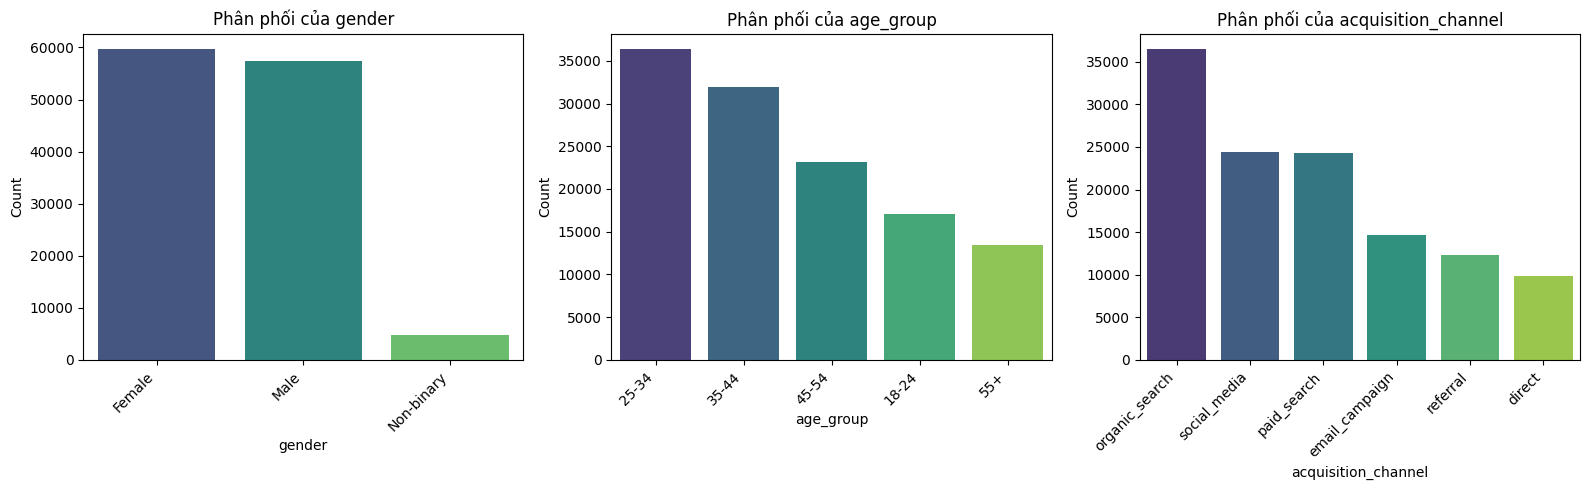

In [ ]:
distribution_analyzer.plot_categorical_distribution(cols=['gender', 'age_group', 'acquisition_channel'])

## payments

### Tổng quan

In [ ]:
eda_unit = EDA(df = payments)
duplicate_and_null_analyzer = DuplicateAndNullAnalyzer(eda_unit.df)   # Kiểm tra trùng lặp và null
distribution_analyzer = DistributionAnalyzer(eda_unit.df)   # Kiểm tra phân phối

In [ ]:
eda_unit.display_dataframe()


--- DataFrame ---


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1
...,...,...,...,...
646940,834372,credit_card,35791.36,3
646941,834377,credit_card,36755.53,3
646942,834387,credit_card,59112.48,1
646943,834392,paypal,23836.65,1


In [ ]:
eda_unit.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


### Phân phối của dữ liệu

In [ ]:
distribution_analyzer.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
            order_id  payment_value   installments
count  646945.000000  646945.000000  646945.000000
mean   417189.470332   24238.334426       3.448319
std    240785.704463   22378.475324       3.119582
min         1.000000     389.740000       1.000000
25%    208728.000000    7681.060000       1.000000
50%    417211.000000   17229.440000       3.000000
75%    625628.000000   33706.350000       6.000000
max    834397.000000  331570.400000      12.000000


In [ ]:
distribution_analyzer.describe_categorical_data()


--- Thống kê biến phân loại ---

Phân phối của payment_method:
payment_method
credit_card      0.550823
paypal           0.149963
cod              0.149442
apple_pay        0.100106
bank_transfer    0.049666
Name: proportion, dtype: float64



--- Phân phối cho biến phân loại ---


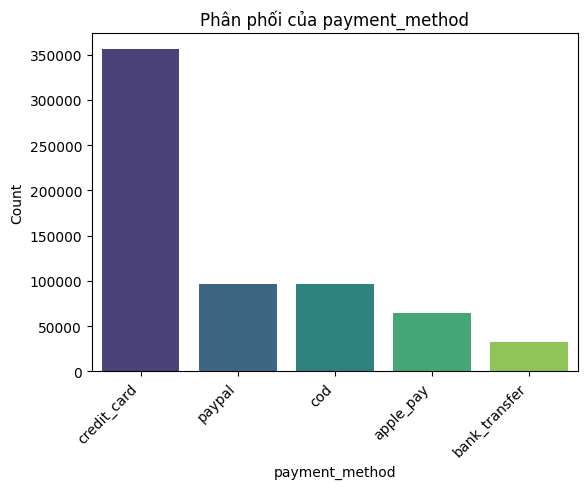

In [ ]:
distribution_analyzer.plot_categorical_distribution()


--- Biểu đồ mật độ ---


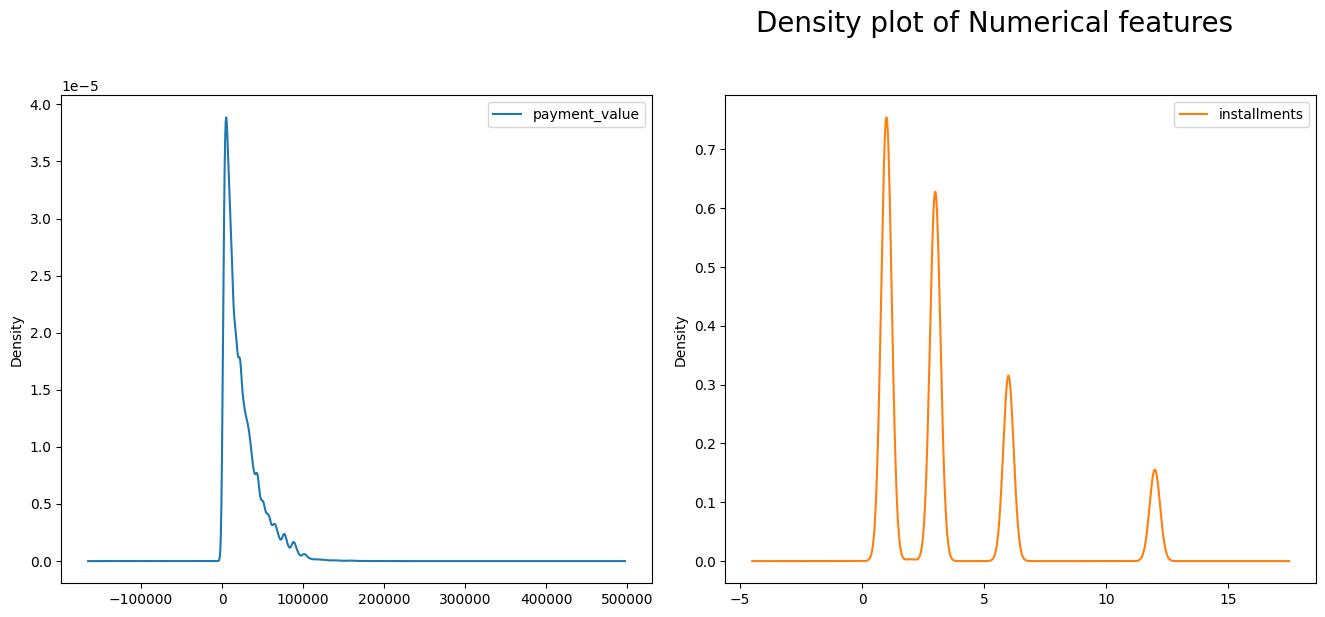

In [ ]:
distribution_analyzer.plot_numerical_density(cols=['payment_value', 'installments'])


--- Boxplot ---


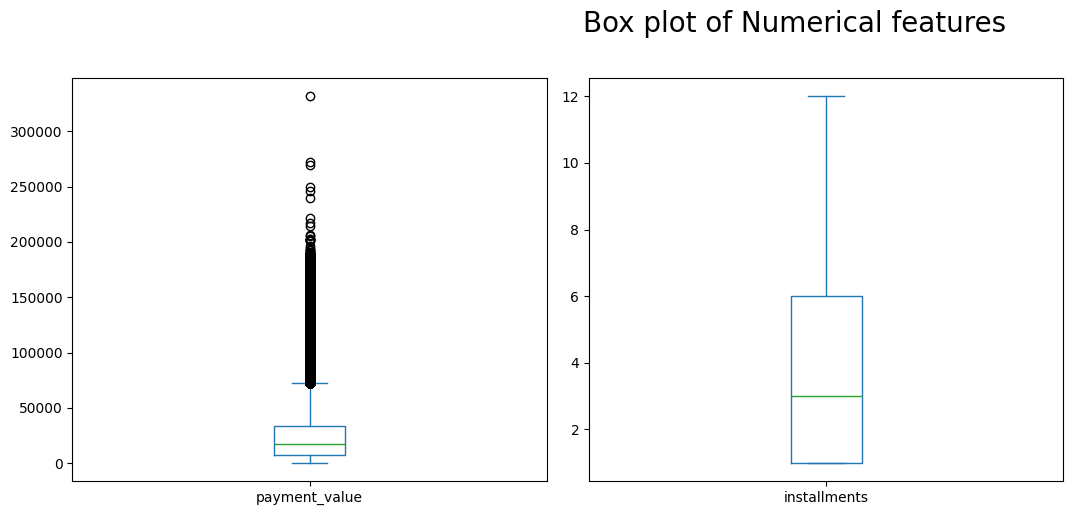

In [ ]:
distribution_analyzer.plot_numerical_boxplot(cols=['payment_value', 'installments'])

In [ ]:
distribution_analyzer.analyze_outlier_impact(numerical_col='payment_value', categorical_col='payment_method')


--- Phân tích giá trị ngoại lai cho payment_value và quan hệ với payment_method ---
Số giá trị 'payment_method' trong nhóm ngoại lai:
payment_method
credit_card      16663
paypal            4560
cod               4535
apple_pay         2965
bank_transfer     1496
Name: count, dtype: int64

Min ngoại lai của payment_value: 72744.91
Max ngoại lai của payment_value: 331570.4


In [ ]:
outliers = distribution_analyzer.find_outliers(col_name='payment_value')
print(f"Số lượng giá trị ngoại lai trong cột payment_value: {len(outliers)}")
print(f"Tỷ lệ ngoại lai: {len(outliers)/len(payments)*100:.3f}%")
print("Top 10 outliers lớn nhất và nhỏ nhất: ")
display(outliers.sort_values(by='payment_value').head(10))
display(outliers.sort_values(by='payment_value', ascending=False).head(10))


Số lượng giá trị ngoại lai trong cột payment_value: 30219
Tỷ lệ ngoại lai: 4.671%
Top 10 outliers lớn nhất và nhỏ nhất: 


,order_id,payment_method,payment_value,installments
250853,323531,cod,72744.91,1
238249,307294,credit_card,72745.68,12
23411,30252,credit_card,72746.94,3
581425,749743,paypal,72747.12,3
611421,788462,apple_pay,72747.85,12
524295,676116,bank_transfer,72748.30,1
578152,745503,apple_pay,72748.76,1
19465,25188,credit_card,72750.80,12
640972,826594,cod,72750.93,1
313601,404567,credit_card,72751.68,6


,order_id,payment_method,payment_value,installments
500803,645732,credit_card,331570.40,12
489769,631538,apple_pay,271911.67,1
488354,629691,credit_card,269154.22,3
469234,605128,cod,250034.88,1
436727,563097,cod,246463.20,1
544853,702612,cod,239627.16,1
628947,811089,bank_transfer,221621.30,3
553460,713659,apple_pay,217184.38,1
613812,791551,credit_card,214492.58,3
452042,582948,credit_card,206329.76,6


Nhận xét: outliers chiếm phần nhỏ trên dữ liệu và không có giá trị ngoại lai vượt trội nào.

## shipments

### Tổng quan

In [ ]:
eda_unit = EDA(df = shipments)
duplicate_and_null_analyzer = DuplicateAndNullAnalyzer(eda_unit.df)   # Kiểm tra trùng lặp và null
distribution_analyzer = DistributionAnalyzer(eda_unit.df)   # Kiểm tra phân phối

In [ ]:
eda_unit.display_dataframe()


--- DataFrame ---


,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79
...,...,...,...,...
566062,834196,2022-12-29,2022-12-31,2.22
566063,834293,2022-12-29,2022-12-31,26.83
566064,834299,2022-12-28,2022-12-31,1.23
566065,834314,2022-12-29,2022-12-31,2.28


In [ ]:
eda_unit.display_info()


--- Thông tin của dataframe: ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       566067 non-null  int64  
 1   ship_date      566067 non-null  object 
 2   delivery_date  566067 non-null  object 
 3   shipping_fee   566067 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 17.3+ MB


### Kiểm tra chất lượng dữ liệu

In [ ]:
duplicate_and_null_analyzer.duplicate_check()


--- Kiểm tra dữ liệu trùng lặp ---
Tổng số hàng trùng lặp: 0


### Phân phối của dữ liệu

In [ ]:
distribution_analyzer.describe_numerical_data()


--- Thống kê mô tả cho dữ liệu số ---
            order_id   shipping_fee
count  566067.000000  566067.000000
mean   415816.869664       4.962857
std    240007.311562       8.887355
min         1.000000       0.000000
25%    208192.500000       0.870000
50%    415866.000000       1.730000
75%    623218.500000       2.600000
max    834325.000000      32.000000


In [ ]:
distribution_analyzer.describe_categorical_data()


--- Thống kê biến phân loại ---

Phân phối của ship_date:
ship_date
2018-06-02    0.001198
2017-06-03    0.001046
2018-06-03    0.001039
2018-06-01    0.001023
2017-06-02    0.000979
                ...   
2021-01-16    0.000037
2021-01-05    0.000037
2021-01-09    0.000035
2022-12-29    0.000035
2020-03-03    0.000019
Name: proportion, Length: 3831, dtype: float64

Phân phối của delivery_date:
delivery_date
2018-06-06    0.000993
2018-06-07    0.000894
2018-06-08    0.000855
2016-05-05    0.000851
2016-05-04    0.000830
                ...   
2021-01-11    0.000041
2021-01-12    0.000037
2021-01-16    0.000034
2012-07-07    0.000026
2012-07-06    0.000011
Name: proportion, Length: 3831, dtype: float64



--- Biểu đồ mật độ ---


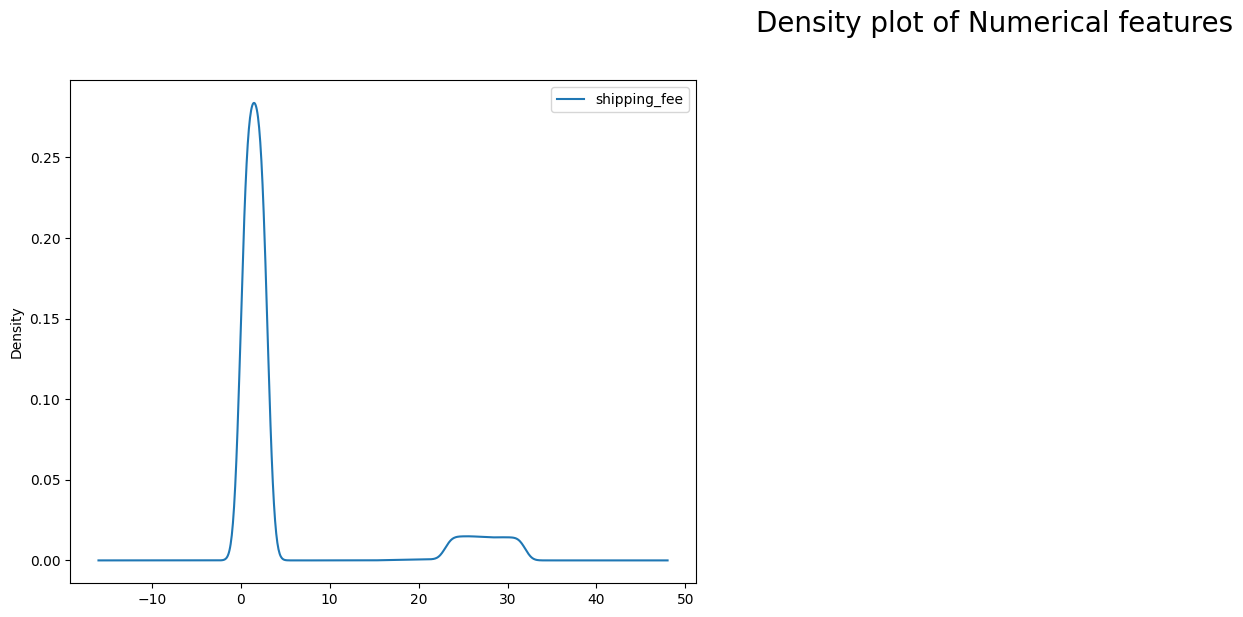

In [ ]:
distribution_analyzer.plot_numerical_density(cols=['shipping_fee'])


--- Boxplot ---


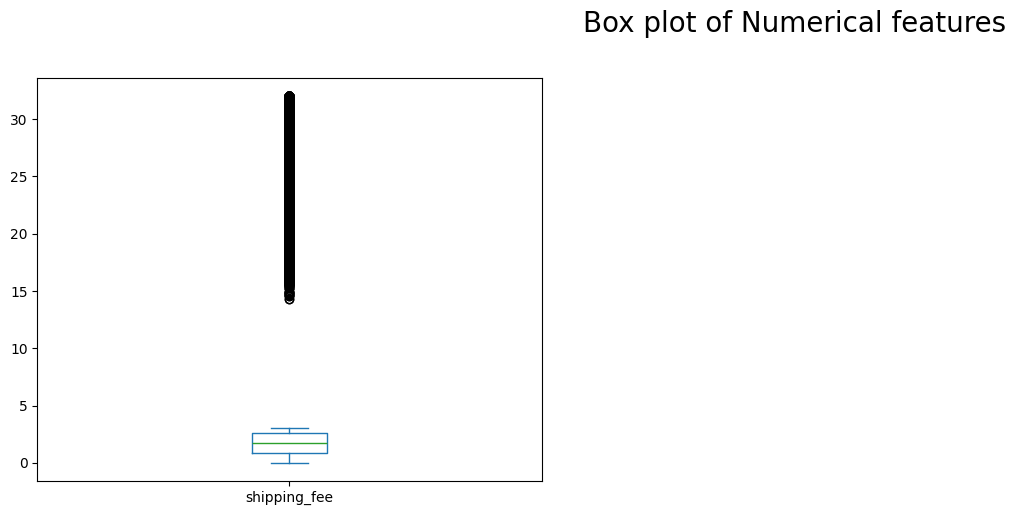

In [ ]:
distribution_analyzer.plot_numerical_boxplot(cols=['shipping_fee'])

In [ ]:
outliers = distribution_analyzer.find_outliers(col_name='shipping_fee')
print(f"Số lượng giá trị ngoại lai trong cột shipping_fee: {len(outliers)}")
print(f"Tỷ lệ ngoại lai: {len(outliers)/len(shipments)*100:.3f}%")
print("Top 10 outliers lớn nhất và nhỏ nhất: ")
display(outliers.sort_values(by='shipping_fee').head(10))
display(outliers.sort_values(by='shipping_fee', ascending=False).head(10))


Số lượng giá trị ngoại lai trong cột shipping_fee: 76050
Tỷ lệ ngoại lai: 13.435%
Top 10 outliers lớn nhất và nhỏ nhất: 


,order_id,ship_date,delivery_date,shipping_fee
237170,348605,2015-12-28,2015-12-30,14.29
67415,99190,2013-07-21,2013-07-24,14.31
304598,447434,2016-11-28,2016-12-05,14.53
91951,135271,2013-12-21,2013-12-25,14.53
565963,833402,2022-12-29,2022-12-31,14.65
64877,95472,2013-07-10,2013-07-14,14.68
374232,549254,2017-12-04,2017-12-08,14.69
93930,138216,2013-12-25,2013-12-30,14.73
91259,134256,2013-12-13,2013-12-16,14.82
378286,555159,2017-12-30,2018-01-06,14.84


,order_id,ship_date,delivery_date,shipping_fee
494215,725728,2020-07-20,2020-07-23,32.0
546831,804362,2022-04-29,2022-05-04,32.0
351605,516286,2017-07-18,2017-07-25,32.0
213573,313834,2015-08-17,2015-08-23,32.0
462840,679648,2019-08-03,2019-08-05,32.0
522759,768060,2021-06-27,2021-07-01,32.0
424387,622980,2018-08-12,2018-08-18,32.0
543756,799755,2022-04-11,2022-04-16,32.0
472446,693692,2019-11-21,2019-11-23,32.0
35847,52815,2013-03-09,2013-03-13,32.0


Có nhiều outliers -> Nhiều khu vực xa hơn nên chi phí cao hơn -> Các outliers không bất thường.

In [ ]:
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments['shipping_time'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
shipments['shipping_time'].value_counts()

,count
shipping_time,
4,94530
6,94410
5,94378
3,94341
2,94299
7,94109


Chênh lệch khoảng thời gian giao hàng phân bố tương đối đều